In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
market = pd.read_csv('video_games.csv')
C_voices = pd.read_csv('all_games.csv')

In [3]:
market.info()

<class 'pandas.DataFrame'>
RangeIndex: 1212 entries, 0 to 1211
Data columns (total 36 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Title                          1212 non-null   str    
 1   Features.Handheld?             1212 non-null   bool   
 2   Features.Max Players           1212 non-null   int64  
 3   Features.Multiplatform?        1212 non-null   bool   
 4   Features.Online?               1212 non-null   bool   
 5   Metadata.Genres                1212 non-null   str    
 6   Metadata.Licensed?             1212 non-null   bool   
 7   Metadata.Publishers            948 non-null    str    
 8   Metadata.Sequel?               1212 non-null   bool   
 9   Metrics.Review Score           1212 non-null   int64  
 10  Metrics.Sales                  1212 non-null   float64
 11  Metrics.Used Price             1212 non-null   float64
 12  Release.Console                1212 non-null   str    
 13 

In [4]:
market.head(7)

,Title,Features.Handheld?,Features.Max Players,Features.Multiplatform?,Features.Online?,Metadata.Genres,Metadata.Licensed?,Metadata.Publishers,Metadata.Sequel?,Metrics.Review Score,...,Length.Main + Extras.Average,Length.Main + Extras.Leisure,Length.Main + Extras.Median,Length.Main + Extras.Polled,Length.Main + Extras.Rushed,Length.Main Story.Average,Length.Main Story.Leisure,Length.Main Story.Median,Length.Main Story.Polled,Length.Main Story.Rushed
0,Super Mario 64 DS,True,1,True,True,Action,True,Nintendo,True,85,...,24.916667,29.966667,25.000000,16,18.333333,14.333333,18.316667,14.500000,21,9.700000
1,Lumines: Puzzle Fusion,True,1,True,True,Strategy,True,Ubisoft,True,89,...,9.750000,9.866667,9.750000,2,9.616667,10.333333,11.083333,10.000000,3,9.583333
2,WarioWare Touched!,True,2,True,True,"Action,Racing / Driving,Sports",True,Nintendo,True,81,...,3.850000,5.666667,3.333333,11,2.783333,1.916667,2.933333,1.833333,30,1.433333
3,Hot Shots Golf: Open Tee,True,1,True,True,Sports,True,Sony,True,81,...,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0,0.000000
4,Spider-Man 2,True,1,True,True,Action,True,Activision,True,61,...,12.766667,17.316667,12.500000,12,10.483333,8.350000,11.083333,8.000000,23,5.333333
5,The Urbz: Sims in the City,True,1,True,True,Simulation,True,EA,True,67,...,20.833333,25.200000,20.000000,3,16.450000,15.500000,15.750000,15.500000,2,15.250000
6,Ridge Racer,True,1,True,True,Racing / Driving,True,Namco,True,88,...,0.883333,0.933333,0.883333,2,0.833333,0.616667,0.783333,0.533333,3,0.450000


In [5]:
C_voices.info()

<class 'pandas.DataFrame'>
RangeIndex: 18800 entries, 0 to 18799
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   index         18800 non-null  int64
 1   name          18800 non-null  str  
 2   platform      18800 non-null  str  
 3   release_date  18800 non-null  str  
 4   summary       18686 non-null  str  
 5   meta_score    18800 non-null  int64
 6   user_review   18800 non-null  str  
dtypes: int64(2), str(5)
memory usage: 1.0 MB


In [6]:
C_voices.head(7)

,index,name,platform,release_date,summary,meta_score,user_review
0,0,The Legend of Zelda: Ocarina of Time,Nintendo 64,"November 23, 1998","As a young boy, Link is tricked by Ganondorf, ...",99,9.1
1,1,Tony Hawk's Pro Skater 2,PlayStation,"September 20, 2000",As most major publishers' development efforts ...,98,7.4
2,2,Grand Theft Auto IV,PlayStation 3,"April 29, 2008",[Metacritic's 2008 PS3 Game of the Year; Also ...,98,7.7
3,3,SoulCalibur,Dreamcast,"September 8, 1999","This is a tale of souls and swords, transcendi...",98,8.4
4,4,Grand Theft Auto IV,Xbox 360,"April 29, 2008",[Metacritic's 2008 Xbox 360 Game of the Year; ...,98,7.9
5,5,Super Mario Galaxy,Wii,"November 12, 2007",[Metacritic's 2007 Wii Game of the Year] The u...,97,9.1
6,6,Super Mario Galaxy 2,Wii,"May 23, 2010","Super Mario Galaxy 2, the sequel to the galaxy...",97,9.1


 
#### first fix datatypes in all games


 user_review: tbd → NaN → float



In [7]:
C_voices['user_review'] = C_voices['user_review'].replace('tbd', np.nan)
C_voices['user_review'] = pd.to_numeric(C_voices['user_review'])
C_voices.info()

<class 'pandas.DataFrame'>
RangeIndex: 18800 entries, 0 to 18799
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   index         18800 non-null  int64  
 1   name          18800 non-null  str    
 2   platform      18800 non-null  str    
 3   release_date  18800 non-null  str    
 4   summary       18686 non-null  str    
 5   meta_score    18800 non-null  int64  
 6   user_review   17435 non-null  float64
dtypes: float64(1), int64(2), str(4)
memory usage: 1.0 MB


convert release date into datetime

In [8]:
C_voices['release_date'] = pd.to_datetime(C_voices['release_date'])

handle the missing values in summary

In [9]:
C_voices['summary']=C_voices['summary'].fillna('No Summary Exists')


handle the missing values in publishers

In [10]:
market['Metadata.Publishers'] =market['Metadata.Publishers'].fillna('Unknown')

In [11]:
market['Metadata.Publishers'].count()

np.int64(1212)

#### Normalize Titles 

In [12]:
market['game_name'] = market['Title'].str.strip().str.lower()
C_voices['game_name'] = C_voices['name'].str.strip().str.lower()


In [13]:
#cheack for special characters
market['game_name'].str.contains(r'[^a-zA-Z0-9\s]', regex=True).sum()


np.int64(593)

In [ ]:
C_voices['game_name'].str.contains(r'[^a-zA-Z0-9\s]', regex=True).sum()


np.int64(8386)

In [15]:
#remove them
market['game_name'] = market['game_name'].str.replace(r'[^a-z0-9\s]', '', regex=True)
C_voices['game_name'] = C_voices['game_name'].str.replace(r'[^a-z0-9\s]', '', regex=True)

In [ ]:
#make sure
print(market['game_name'].str.contains(r'[^a-z0-9\s]', regex=True).sum()) 
print(C_voices['game_name'].str.contains(r'[^a-z0-9\s]', regex=True).sum()) 

0
0


#### pre-merge


##### as game name alone is not enough due to multiple platforms so the common identifier will be game name + specific platform

In [17]:
market['Release.Console'].unique()

<StringArray>
['Nintendo DS', 'Sony PSP', 'X360', 'Nintendo Wii', 'PlayStation 3']
Length: 5, dtype: str

In [18]:
C_voices['platform'].unique()

<StringArray>
[     ' Nintendo 64',      ' PlayStation',    ' PlayStation 3',
        ' Dreamcast',         ' Xbox 360',              ' Wii',
         ' Xbox One',               ' PC',           ' Switch',
    ' PlayStation 2',    ' PlayStation 4',         ' GameCube',
             ' Xbox',            ' Wii U', ' Game Boy Advance',
              ' 3DS',    ' Xbox Series X',               ' DS',
 ' PlayStation Vita',    ' PlayStation 5',              ' PSP',
           ' Stadia']
Length: 22, dtype: str

In [19]:
#just to make sure that 'DS' is Nintendo DS
C_voices.loc[C_voices['platform'] == ' DS', 'game_name'].tolist()

['grand theft auto chinatown wars',
 'flipnote studio',
 'chrono trigger',
 'mario kart ds',
 'mario  luigi bowsers inside story',
 'the legend of zelda phantom hourglass',
 'advance wars dual strike',
 'castlevania dawn of sorrow',
 'new super mario bros',
 'meteos',
 'the world ends with you',
 'pokemon white version',
 'dragon quest ix sentinels of the starry skies',
 'pokemon soulsilver version',
 'elite beat agents',
 'the legend of zelda spirit tracks',
 'pokemon heartgold version',
 'pokemon black version',
 'kirby canvas curse',
 'might  magic clash of heroes',
 'mario  luigi partners in time',
 'planet puzzle league',
 'animal crossing wild world',
 'professor layton and the unwound future',
 'advance wars days of ruin',
 'radiant historia',
 'shantae riskys revenge',
 'castlevania portrait of ruin',
 'metroid prime hunters',
 'pokemon pearl version',
 'the legend of zelda four swords anniversary edition',
 'professor layton and the curious village',
 'super mario 64 ds',
 'po

#### Since market has fewer platforms we can only use games available on those platforms 
['Nintendo DS', 'Sony PSP', 'X360', 'Nintendo Wii', 'PlayStation 3']

##### first step is to make the names consistent across both datasets

In [20]:
C_voices['platform'] = C_voices['platform'].str.strip()
platform_mapping = {
    'Xbox 360'    : 'X360',
    'Wii'         : 'Nintendo Wii',
    'PSP'         : 'Sony PSP',
    'DS'          : 'Nintendo DS',
    
}
C_voices['platform'] = C_voices['platform'].replace(platform_mapping)

In [21]:
C_voices =C_voices[C_voices['platform'].isin(market['Release.Console'].unique())]

In [22]:
set(C_voices['platform'].unique())- set(market['Release.Console'].unique())

set()

In [23]:
C_voices['platform'].unique()

<StringArray>
['PlayStation 3', 'X360', 'Nintendo Wii', 'Nintendo DS', 'Sony PSP']
Length: 5, dtype: str

#### Merging

In [24]:
merged_all = pd.merge( market, C_voices, left_on=['game_name', 'Release.Console'], right_on=['game_name', 'platform'], how='left')

In [25]:
print(merged_all.shape)
print(merged_all['meta_score'].notna().sum()) 
print(merged_all.duplicated(subset=['game_name', 'Release.Console']).sum())  

(1218, 44)
946
6


In [26]:
duplicates = merged_all[merged_all.duplicated(subset=['game_name', 'Release.Console'], keep=False )]
duplicates.head()

,Title,Features.Handheld?,Features.Max Players,Features.Multiplatform?,Features.Online?,Metadata.Genres,Metadata.Licensed?,Metadata.Publishers,Metadata.Sequel?,Metrics.Review Score,...,Length.Main Story.Polled,Length.Main Story.Rushed,game_name,index,name,platform,release_date,summary,meta_score,user_review
308,X-Men: The Official Game,True,1,True,True,Action,True,Activision,True,52,...,2,11.750000,xmen the official game,17266.0,X-Men: The Official Game,X360,2006-05-16,Master the power of the X-Men—Obliterate enemi...,52.0,7.2
309,X-Men: The Official Game,True,1,True,True,Action,True,Activision,True,52,...,2,11.750000,xmen the official game,17285.0,X-Men: The Official Game,X360,2006-05-16,Master the power of the X-Men—Obliterate enemi...,52.0,6.4
705,The Golden Compass,True,1,True,True,Action,True,Sega,True,40,...,4,5.883333,the golden compass,18368.0,The Golden Compass,PlayStation 3,2007-12-04,The Golden Compass follows the screenplay adap...,41.0,4.3
706,The Golden Compass,True,1,True,True,Action,True,Sega,True,40,...,4,5.883333,the golden compass,18436.0,The Golden Compass,PlayStation 3,2007-12-04,The Golden Compass follows the screenplay adap...,40.0,4.8
743,Fantastic Four: Rise of the Silver Surfer,True,4,True,True,Action,True,2K,True,45,...,4,5.016667,fantastic four rise of the silver surfer,17855.0,Fantastic Four: Rise of the Silver Surfer,X360,2007-06-15,Marvel’s first family of Super Heroes face its...,47.0,5.6


In [27]:
#trial to solve the duplicates with the score and reviews
merged_all = merged_all.groupby(
    ['game_name', 'Release.Console'], 
    as_index=False
).agg({
    'meta_score'   : 'mean',
    'user_review'  : 'mean',
     **{col: 'first' for col in merged_all.columns 
       if col not in ['game_name', 'Release.Console', 'meta_score', 'user_review']}
})


In [ ]:
print(merged_all.shape)

(1212, 44)


In [29]:
duplicates = merged_all[merged_all.duplicated(subset=['game_name', 'Release.Console'], keep=False )]
duplicates.head()

,game_name,Release.Console,meta_score,user_review,Title,Features.Handheld?,Features.Max Players,Features.Multiplatform?,Features.Online?,Metadata.Genres,...,Length.Main Story.Average,Length.Main Story.Leisure,Length.Main Story.Median,Length.Main Story.Polled,Length.Main Story.Rushed,index,name,platform,release_date,summary


now time to remove unnecessary columns

In [30]:
print(merged_all.columns.tolist())

['game_name', 'Release.Console', 'meta_score', 'user_review', 'Title', 'Features.Handheld?', 'Features.Max Players', 'Features.Multiplatform?', 'Features.Online?', 'Metadata.Genres', 'Metadata.Licensed?', 'Metadata.Publishers', 'Metadata.Sequel?', 'Metrics.Review Score', 'Metrics.Sales', 'Metrics.Used Price', 'Release.Rating', 'Release.Re-release?', 'Release.Year', 'Length.All PlayStyles.Average', 'Length.All PlayStyles.Leisure', 'Length.All PlayStyles.Median', 'Length.All PlayStyles.Polled', 'Length.All PlayStyles.Rushed', 'Length.Completionists.Average', 'Length.Completionists.Leisure', 'Length.Completionists.Median', 'Length.Completionists.Polled', 'Length.Completionists.Rushed', 'Length.Main + Extras.Average', 'Length.Main + Extras.Leisure', 'Length.Main + Extras.Median', 'Length.Main + Extras.Polled', 'Length.Main + Extras.Rushed', 'Length.Main Story.Average', 'Length.Main Story.Leisure', 'Length.Main Story.Median', 'Length.Main Story.Polled', 'Length.Main Story.Rushed', 'index', 

In [31]:
merged_all = merged_all.drop(columns=['index', 'name','Title','platform', 'summary', 'release_date'])
merged_all.shape[0]

1212

In [32]:
merged_all.columns

Index(['game_name', 'Release.Console', 'meta_score', 'user_review',
       'Features.Handheld?', 'Features.Max Players', 'Features.Multiplatform?',
       'Features.Online?', 'Metadata.Genres', 'Metadata.Licensed?',
       'Metadata.Publishers', 'Metadata.Sequel?', 'Metrics.Review Score',
       'Metrics.Sales', 'Metrics.Used Price', 'Release.Rating',
       'Release.Re-release?', 'Release.Year', 'Length.All PlayStyles.Average',
       'Length.All PlayStyles.Leisure', 'Length.All PlayStyles.Median',
       'Length.All PlayStyles.Polled', 'Length.All PlayStyles.Rushed',
       'Length.Completionists.Average', 'Length.Completionists.Leisure',
       'Length.Completionists.Median', 'Length.Completionists.Polled',
       'Length.Completionists.Rushed', 'Length.Main + Extras.Average',
       'Length.Main + Extras.Leisure', 'Length.Main + Extras.Median',
       'Length.Main + Extras.Polled', 'Length.Main + Extras.Rushed',
       'Length.Main Story.Average', 'Length.Main Story.Leisure',
     

#### Analysis 

In [33]:
#Starting with Global Stats
S_sales = {
    'Mean': np.mean(merged_all['Metrics.Sales']),
    'Median': np.median(merged_all['Metrics.Sales']),
    'Max': np.max(merged_all['Metrics.Sales']),
    'Min': np.min(merged_all['Metrics.Sales'])
}

print("Sales Statistics ", S_sales) #in games sales are in millions

Sales Statistics  {'Mean': np.float64(0.5031600660066006), 'Median': np.float64(0.21), 'Max': np.float64(14.66), 'Min': np.float64(0.01)}


In [34]:
#just making it look better
df_S_stats = pd.DataFrame(S_sales.items(), columns=['Metric', 'Value'])
df_S_stats['Value'] = df_S_stats['Value'].round(2)

display(df_S_stats.style.set_caption("Sales Summary").background_gradient(cmap='Blues', subset=['Value']))

,Metric,Value
0,Mean,0.500000
1,Median,0.210000
2,Max,14.660000
3,Min,0.010000


keep in mind there is an outlier (big one)  
will try to find out the source of it and how to deal with it

In [35]:
R_stats = {
    'Mean': np.mean(merged_all['meta_score']),
    'Median': np.nanmedian(merged_all['meta_score']), #nanmedian as the default median had been affected by the missing values
    'Max': np.max(merged_all['meta_score']),
    'Min': np.min(merged_all['meta_score'])
}
print("Rating Statistics", R_stats)
df_R_stats = pd.DataFrame(R_stats.items(), columns=['Metric', 'Value'])
df_R_stats['Value'] = df_R_stats['Value'].round(2)

display(df_R_stats.style.set_caption("Rating Summary").background_gradient(cmap='Blues', subset=['Value']))

Rating Statistics {'Mean': np.float64(72.32765957446809), 'Median': np.float64(73.0), 'Max': np.float64(98.0), 'Min': np.float64(25.0)}


,Metric,Value
0,Mean,72.330000
1,Median,73.000000
2,Max,98.000000
3,Min,25.000000


### Sales by Platform or Genre

 Genre Analysis (Primary Focus)

In [36]:
A_Genre = merged_all.groupby('Metadata.Genres').agg({
    'Metrics.Sales': ['mean', 'sum', 'count'],
    'meta_score': 'mean'
})
#Added meta_score to evaluate both sales performance and review quality across genres.
A_Genre.columns = ['Avg_Sales' ,'Total_Sales','Game_Count', 'Avg_Score']


In [37]:
A_Genre.head(10).style.background_gradient(cmap='Blues', subset=['Avg_Sales' , 'Avg_Score'])

,Avg_Sales,Total_Sales,Game_Count,Avg_Score
Metadata.Genres,,,,
Action,0.527983,251.320000,476,71.007042
"Action,Adventure",0.199286,5.580000,28,66.904762
"Action,Adventure,Racing / Driving",0.086667,0.260000,3,62.000000
"Action,Adventure,Racing / Driving,Sports",0.235000,0.470000,2,77.000000
"Action,Adventure,Role-Playing (RPG)",0.227500,0.910000,4,76.500000
"Action,Adventure,Strategy",0.060000,0.060000,1,80.000000
"Action,Educational",0.010000,0.010000,1,nan
"Action,Racing / Driving",0.767000,30.680000,40,75.515152
"Action,Racing / Driving,Role-Playing (RPG)",0.430000,1.290000,3,78.333333


Platform analysis (The Secondary Factor)  

In [38]:
A_Platform = merged_all.groupby('Release.Console').agg({
    'Metrics.Sales': ['mean', 'sum', 'count']
})
A_Platform.columns = ['Avg_Sales','Total_Sales', 'Game_Count']
A_Platform.style.background_gradient(cmap='Blues', subset=['Total_Sales'])


,Avg_Sales,Total_Sales,Game_Count
Release.Console,,,
Nintendo DS,0.508927,161.330000,317
Nintendo Wii,0.731123,136.720000,187
PlayStation 3,0.452291,80.960000,179
Sony PSP,0.262769,63.590000,242
X360,0.582683,167.230000,287


Genre-Platform relationship

In [39]:
#what i am trying to reach here ? calculate the average sales of each game genre on each platform separately
S_Genre_Platform = (
    merged_all.groupby(['Release.Console', 'Metadata.Genres'])['Metrics.Sales']
    .mean()
    .reset_index()
    .rename(columns={'Metrics.Sales': 'Avg_Sales_Per_Game'})
)
S_Genre_Platform.head(3)

,Release.Console,Metadata.Genres,Avg_Sales_Per_Game
0,Nintendo DS,Action,0.514706
1,Nintendo DS,"Action,Adventure",0.188889
2,Nintendo DS,"Action,Adventure,Racing / Driving",0.050000


noticed that some games are categorized under multiple genres  
to solve this ?  
use explode function to split the genres into separate rows 

In [40]:
merged_all['Genre_List'] = merged_all['Metadata.Genres'].str.split(',')
df_exploded = merged_all.explode('Genre_List')
df_exploded['Genre_List'] = df_exploded['Genre_List'].str.strip()

In [ ]:
A_Genre = df_exploded.groupby('Genre_List').agg(
    Avg_Sales  = ('Metrics.Sales', 'mean'),
    Total_Sales= ('Metrics.Sales', 'sum'),
    Game_Count = ('Metrics.Sales', 'count'),
    Avg_Score  = ('meta_score', 'mean')
).sort_values('Avg_Sales', ascending=False)

In [42]:
S_Genre_Platform = (
    df_exploded.groupby(['Release.Console', 'Genre_List'])['Metrics.Sales']
    .mean()
    .reset_index()
    .rename(columns={'Metrics.Sales': 'Avg_Sales_Per_Game', 'Genre_List': 'Genre'})
)
S_Genre_Platform = S_Genre_Platform.sort_values(by='Avg_Sales_Per_Game', ascending=False)
S_Genre_Platform.head()

,Release.Console,Genre,Avg_Sales_Per_Game
10,Nintendo Wii,Educational,9.600000
14,Nintendo Wii,Sports,1.198125
11,Nintendo Wii,Racing / Driving,0.983000
5,Nintendo DS,Simulation,0.790263
8,Nintendo Wii,Action,0.735426


The table below shows the highest average sales across different platform and genre combinations

In [ ]:
#identify the best-performing genre for each platform then rank them
best_per_platform = S_Genre_Platform.loc[
    S_Genre_Platform.groupby('Release.Console')['Avg_Sales_Per_Game'].idxmax()
].sort_values(by='Avg_Sales_Per_Game', ascending=False)
best_per_platform.head()

,Release.Console,Genre,Avg_Sales_Per_Game
10,Nintendo Wii,Educational,9.600000
5,Nintendo DS,Simulation,0.790263
31,X360,Action,0.686328
18,PlayStation 3,Racing / Driving,0.604167
26,Sony PSP,Racing / Driving,0.443824


####  Trend Analysis

Analyze game releases over years:  
1-group by Year

In [44]:
over_years = merged_all.groupby('Release.Year').agg({
    'Metrics.Sales': ['mean', 'sum', 'count'],
    'Metrics.Review Score': 'mean'
}).reset_index()

over_years.columns = ['Year', 'Avg_Sales', 'Total_Sales', 'Game_Count', 'Avg_Rating']
over_years.head()

,Year,Avg_Sales,Total_Sales,Game_Count,Avg_Rating
0,2004,0.439091,9.66,22,69.772727
1,2005,0.564851,75.69,134,70.164179
2,2006,0.504829,132.77,263,69.076046
3,2007,0.482681,199.83,414,67.519324
4,2008,0.506280,191.88,379,69.559367


The number of released games increased a lot  
average sales improved slightly  
average ratings stayed almost the same -> a weak relationship between ratings and sales


In [ ]:
#checking on this relationship 
merged_all['Metrics.Sales'].corr(merged_all['Metrics.Review Score'])

np.float64(0.29787027313969966)

yaeh ratings are not a strong predictor of sales

### Visualization


##### Which are the top-selling games ?

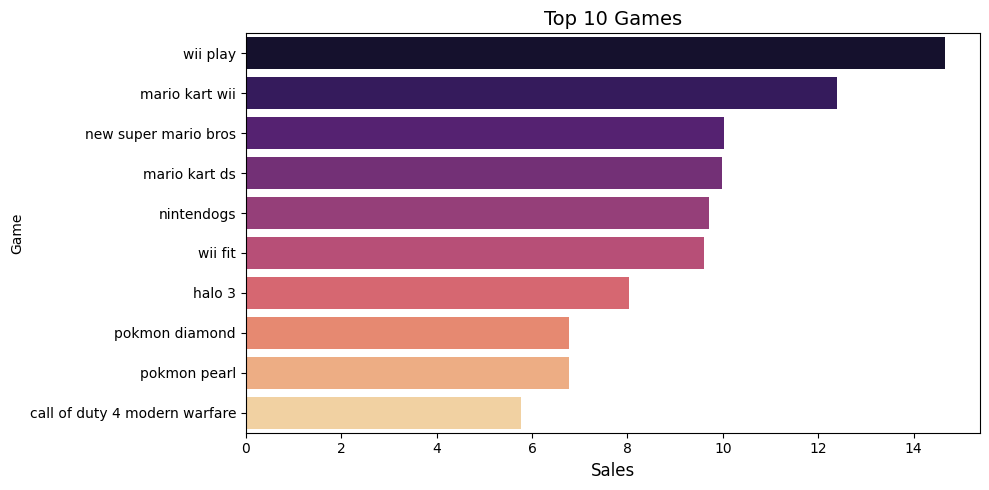

In [63]:
top_10 = merged_all.nlargest(10, 'Metrics.Sales')[['game_name', 'Metrics.Sales', 'Metrics.Review Score']]
plt.figure(figsize=(10, 5))
sns.barplot(data=top_10, x='Metrics.Sales', y='game_name',hue='game_name', palette='magma')
plt.title('Top 10 Games', fontsize=14, fontweight='light')
plt.xlabel('Sales', fontsize=12)
plt.ylabel('Game')
plt.tight_layout()
plt.show()

#### What game genres actually Sell the Best?

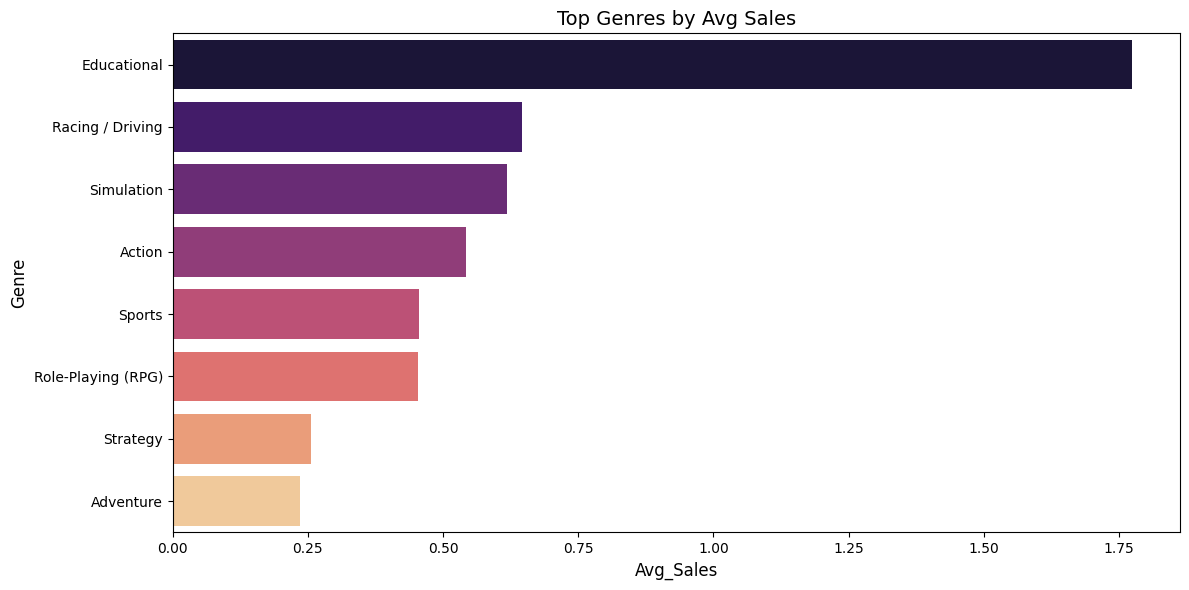

In [71]:
plt.figure(figsize=(12, 6))
sns.barplot(data=A_Genre.reset_index().head(10), x='Avg_Sales', y='Genre_List',
            hue='Genre_List', palette='magma', legend=False)
plt.title('Top Genres by Avg Sales', fontsize=14, fontweight='light')
plt.xlabel('Avg_Sales', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.tight_layout()
plt.show()

#### Which platform has the highest average sales per game?

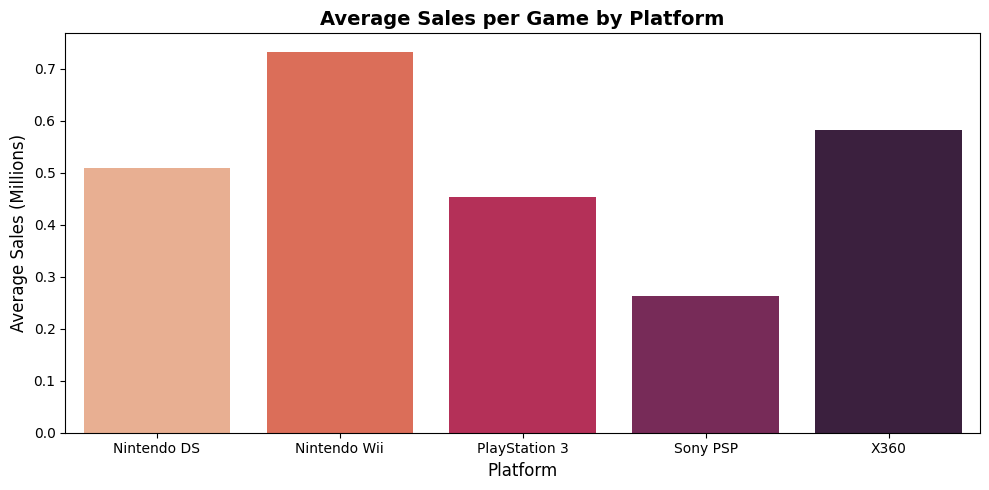

In [66]:
plt.figure(figsize=(10, 5))
sns.barplot(data=A_Platform.reset_index(), x='Release.Console', y='Avg_Sales',hue='Release.Console', palette='rocket_r', legend=False)
plt.title('Average Sales per Game by Platform', fontsize=14, fontweight='bold')
plt.xlabel('Platform', fontsize=12)
plt.ylabel('Average Sales (Millions)', fontsize=12)
plt.tight_layout()
plt.show()

#### Has the market grown over the years?

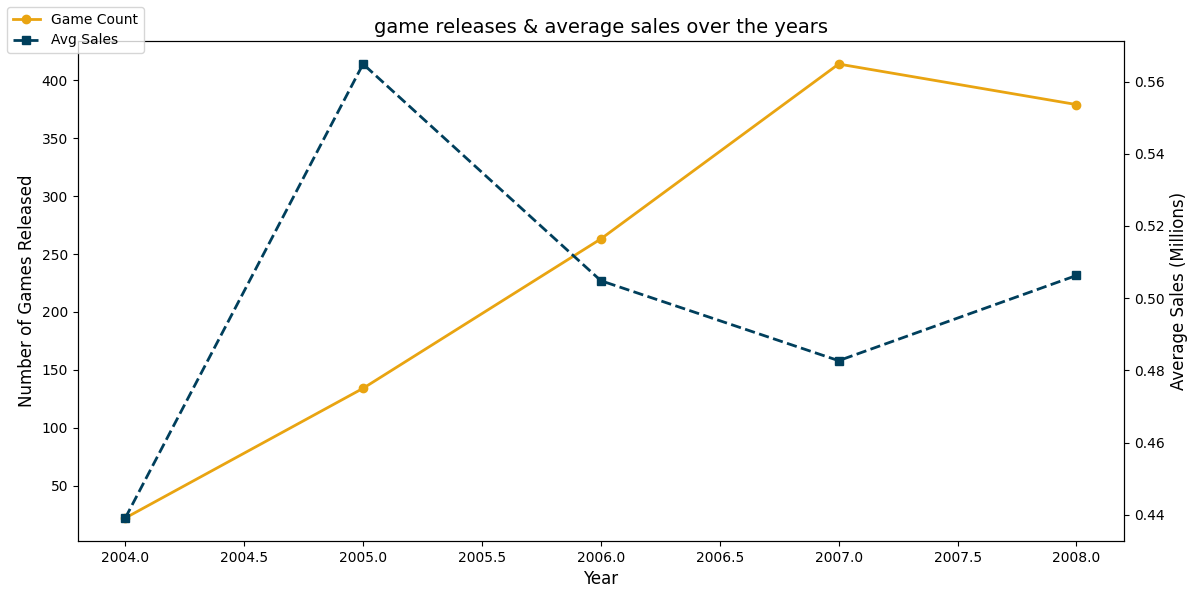

In [73]:
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Number of Games Released',fontsize=12)
ax1.plot(over_years['Year'], over_years['Game_Count'], color='#e9a411', marker='o', linewidth=2, label='Game Count')
ax1.tick_params(axis='y')

ax2 = ax1.twinx()
ax2.set_ylabel('Average Sales (Millions)', fontsize=12)
ax2.plot(over_years['Year'], over_years['Avg_Sales'], color='#003f5c', marker='s', linewidth=2, linestyle='--', label='Avg Sales')
ax2.tick_params(axis='y')

plt.title('game releases & average sales over the years', fontsize=14, fontweight='light')
fig.legend(loc='upper left')
plt.tight_layout()
plt.show()


This suggests that more games being released doesn’t necessarily mean each game sells better

#### Which platform consistently gets the highest-rated games?

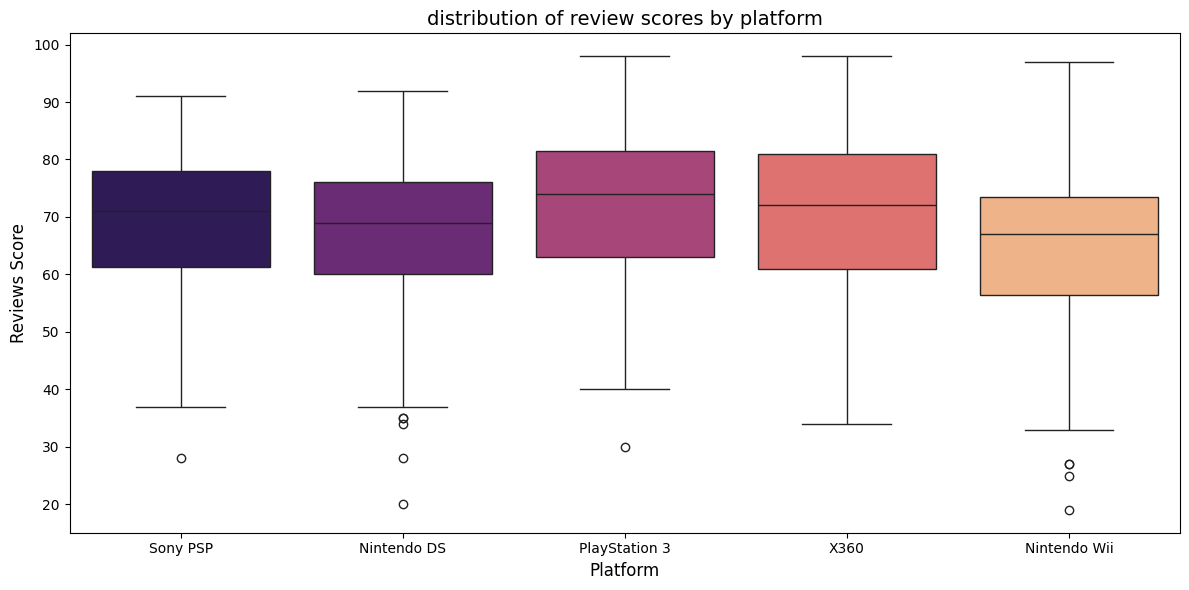

In [74]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=merged_all, x='Release.Console', y='Metrics.Review Score',
            hue='Release.Console', palette='magma', legend=False)
plt.title('distribution of review scores by platform', fontsize=14, fontweight='light')
plt.xlabel('Platform', fontsize=12)
plt.ylabel('Reviews Score', fontsize=12)
plt.tight_layout()
plt.show()

Games on PS3 and Xbox 360 generally receive better critical ratings

#### Is there a real relationship between ratings, sales , playtime , price

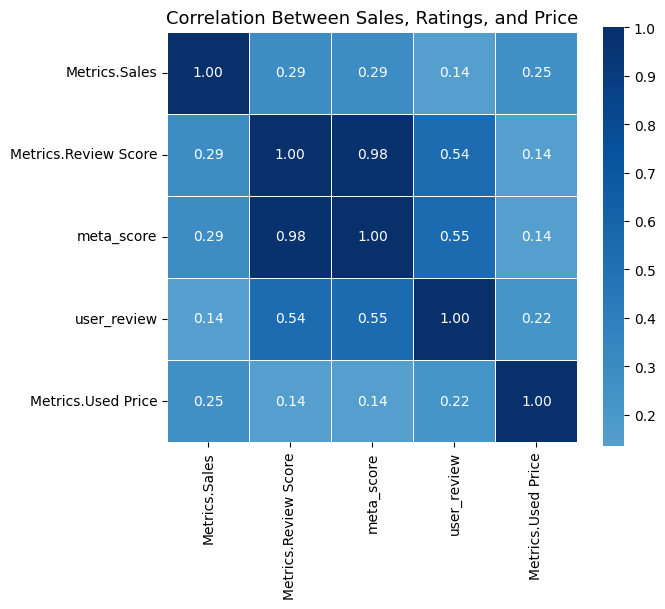

In [84]:
cols = [
    'Metrics.Sales',
    'Metrics.Review Score',
    'meta_score',
    'user_review',
    'Metrics.Used Price'
]

corr_df = merged_all[cols].dropna()
corr_matrix = corr_df.corr()
plt.figure(figsize=(7,6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Blues',
            center=0, linewidths=0.5, square=True)

plt.title('Correlation Between Sales, Ratings, and Price', fontsize=13)
plt.tight_layout()
plt.show()

#### Final Conclusions & Recommendations

##### Main Project Question:
Should we invest in highly rated games, high-selling games, or is there a relationship between both?  

the following conclusions were reached:
There is no strong relationship between game review scores and sales performance  

- The correlation between `Metrics.Review Score` and `Metrics.Sales` is **0.298**, indicating a weak positive relationship.  
- This means that high review scores do not necessarily guarantee high sales  
(some moderately rated games achieve massive commercial success)  

**Conclusion:** relying only on critic ratings when making investment decisions is not a safe  


investment decisions should consider both:
- **Sales trends** to understand market demand and profitability  
- **Review scores** to measure game quality and player/critic reception  
(prioritize games with strong sales potential while maintaining acceptable review scores)

----


#### Extra analysis  
Out of curiosity  
Do games that are part of a series makee higher average sales compared to original games?

avg_Sales for Sequels: 0.52 millions
avg_Sales for Originals: 0.47 millions
increase:10.2%


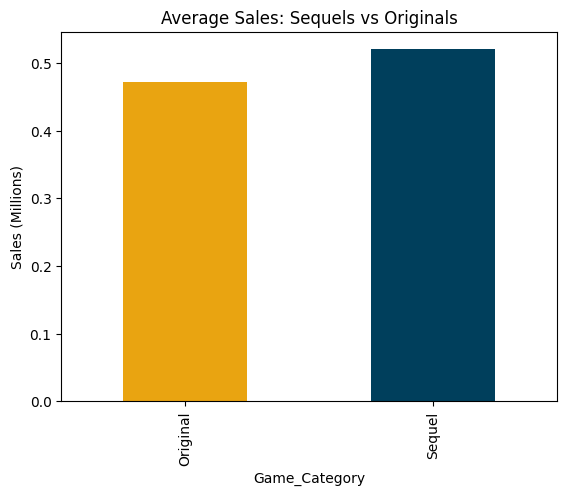

In [95]:

merged_all['name_again'] = merged_all['game_name'].apply(lambda x: " ".join(str(x).split()[:2]))
series_counts = merged_all['name_again'].value_counts()
merged_all['Game_Category'] = merged_all['name_again'].apply(lambda x: 'Sequel' if series_counts[x] > 1 else 'Original')

comparison = merged_all.groupby('Game_Category')['Metrics.Sales'].mean()

avg_sequel = comparison['Sequel']
avg_original = comparison['Original']
increase= ((avg_sequel - avg_original) / avg_original) * 100

print(f"avg_Sales for Sequels: {avg_sequel:.2f} millions")
print(f"avg_Sales for Originals: {avg_original:.2f} millions")
print(f"increase:{increase:.1f}%")

comparison.plot(kind='bar', color=['#e9a411', '#003f5c'])
plt.title('Average Sales: Sequels vs Originals')
plt.ylabel('Sales (Millions)')
plt.show()

Out of curiosity again!  
Do multi-platform games generate higher average sales compared to exclusive

avg_Sales for Multi-Platform games: 0.47 millions
avg_Sales for Exclusive games: 0.53 millions
increase: -10.0%


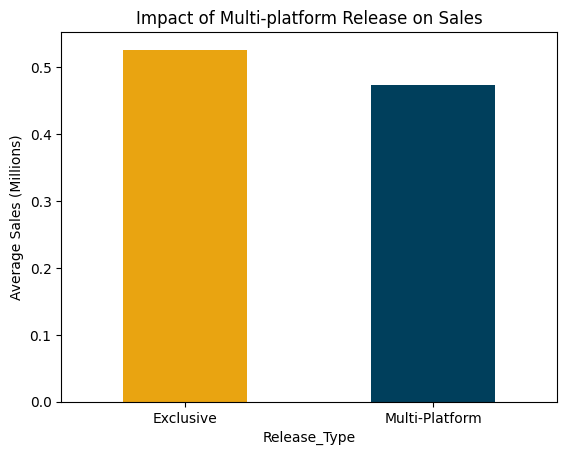

In [96]:

merged_all['platform_count'] = merged_all.groupby('game_name')['Release.Console'].transform('nunique')

#categorize games into 'Multi-Platform' and 'Exclusive'
merged_all['Release_Type'] = merged_all['platform_count'].apply(lambda x: 'Multi-Platform' if x > 1 else 'Exclusive')

#calculate the average sales for each platform
platform_impact = merged_all.groupby('Release_Type')['Metrics.Sales'].mean()

avg_multi = platform_impact['Multi-Platform']
avg_exclusive = platform_impact['Exclusive']
increase_pct = ((avg_multi - avg_exclusive) / avg_exclusive) * 100

print(f"avg_Sales for Multi-Platform games: {avg_multi:.2f} millions")
print(f"avg_Sales for Exclusive games: {avg_exclusive:.2f} millions")
print(f"increase: {increase_pct:.1f}%")

platform_impact.plot(kind='bar', color=['#e9a411', '#003f5c'])
plt.title('Impact of Multi-platform Release on Sales')
plt.ylabel('Average Sales (Millions)')
plt.xticks(rotation=0)
plt.show()